# RL-based Search for FlexTok Tokens

This notebook demonstrates how to use reinforcement learning agents to search over the FlexTok token space.

The RL agent learns to sequentially pick token values that minimize perceptual similarity to a target image.

In [6]:
# Setup
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '4'

import sys
sys.path.append('..')

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from flextok.utils.misc import detect_bf16_support
from twenty_questions.twenty_questions import load_flextok_model, convert_images_to_pil
from flextok.utils.dataloader import CelebAHQDataset, create_celeb_dataloader

# RL imports
from rl_search.environment import FlexTokSearchEnv
from rl_search.reward_shaping import RewardShaper, create_reward_shaper
from rl_search.agents import create_agent
from rl_search.eval_utils import (
    evaluate_agent, 
    visualize_episode, 
    compare_agents,
    visualize_search_trajectory,
    analyze_token_distribution,
)

# Automatically set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)

# Detect if bf16 is enabled
enable_bf16 = detect_bf16_support()
print('BF16 enabled:', enable_bf16)

Device: cuda
BF16 enabled: True


## 1. Load FlexTok Model and Target Image

In [8]:
# Load FlexTok model
CKPT_PATH = "/home/iyu/ml-flextok/checkpoints/celeba_d18_arcface_fsq_8/20260108/checkpoint_best.pt"
FSQ_LEVELS = [8]

model = load_flextok_model(
    ckpt_path=CKPT_PATH,
    fsq_level=FSQ_LEVELS
).to(device)

print(f"Model loaded with FSQ levels: {FSQ_LEVELS}")

Overriding FSQ levels with: [8]
Adjusting encoder output dimension from 6 to 1
Adjusting decoder input dimension to 1
Model loaded with FSQ levels: [8]


Loaded target image (index 945)


/home/iyu/ml-flextok/flextok/utils/dataloader.py:74: UserWarning: No ID mapping file found in /home/iyu/ml-flextok/data/celebahq/ids. Continuing without ID mappings.
  warnings.warn(


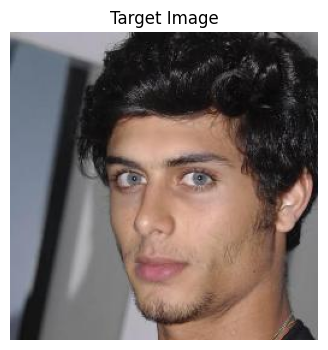

In [12]:
# Load target image from dataset
IMG_SIZE = 256
DATASET_NAME = "celebahq"
DATASET_PATH = f"/home/iyu/ml-flextok/data/{DATASET_NAME}/"
np.random.seed(420)  # For reproducibility

val_dataset = CelebAHQDataset(
    root_dir=DATASET_PATH,
    img_size=IMG_SIZE,
    split="val",
)
# Get a random target image
idx = np.random.randint(0, len(val_dataset))
target_tensor = val_dataset[idx].unsqueeze(0).to(device)
target_image = convert_images_to_pil(target_tensor)[0]

print(f"Loaded target image (index {idx})")
plt.figure(figsize=(4, 4))
plt.imshow(target_image)
plt.title("Target Image")
plt.axis('off')
plt.show()

## 2. Load Similarity Model (DreamSim)

In [13]:
from dreamsim import dreamsim

# Load DreamSim model
dreamsim_model, dreamsim_preprocess = dreamsim(pretrained=True, device=device)

print("DreamSim model loaded")

Using cached ./models


Using cache found in ./models/facebookresearch_dino_main
/home/iyu/miniconda3/envs/flextok/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


DreamSim model loaded


/home/iyu/miniconda3/envs/flextok/lib/python3.10/site-packages/peft/tuners/tuners_utils.py:282: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


In [14]:
# Create similarity function
def similarity_fn(img1: Image.Image, img2: Image.Image) -> float:
    """Compute DreamSim similarity score between two PIL images."""
    # dreamsim_preprocess already adds batch dimension, so no need to unsqueeze
    img1_tensor = dreamsim_preprocess(img1).to(device)
    img2_tensor = dreamsim_preprocess(img2).to(device)
    
    with torch.no_grad():
        score = dreamsim_model(img1_tensor, img2_tensor)
    
    return float(score.item())

## 3. Create RL Environment

In [22]:
# Create reward shaper
reward_config = {
    'type': 'simple',
    'mode': 'improvement',  # Options: 'negative', 'inverse', 'exponential', 'improvement'
}
reward_shaper = create_reward_shaper(reward_config)

from rl_search.multi_target_wrapper import (
    MultiTargetWrapper,
    DatasetTargetSampler,
    FixedSetTargetSampler,
)

# Create a sampler that randomly picks target images from the validation set
target_sampler = DatasetTargetSampler(
    dataset=val_dataset,
    convert_fn=lambda x: convert_images_to_pil(x.unsqueeze(0).to(device))[0],
    device=device,
    seed=42,  # For reproducibility
)

# Create environment (start with any initial target)
general_env = FlexTokSearchEnv(
    flextok_model=model,
    target_image=target_image,  # Initial target (will be replaced)
    similarity_fn=similarity_fn,
    fsq_levels=FSQ_LEVELS,
    max_tokens=256,
    history_length=5,
    enable_bf16=enable_bf16,
    device=device,
    goal_threshold=0.1,
    enable_undo=True,
    image_obs=True,  # Disable image observations for faster training
    reward_shaper=reward_shaper,
)

# Wrap with MultiTargetWrapper to sample new targets each episode
general_env = MultiTargetWrapper(general_env, target_sampler=target_sampler)

print("Multi-target environment created")
print("Each episode will use a different random target image from the dataset")

Multi-target environment created
Each episode will use a different random target image from the dataset


## 4. Create and Train RL Agent

We'll create a DQN agent (best for discrete action spaces like FSQ [8]).

In [23]:
# Create a general agent that can work with any target
general_agent_config = {
    'learning_rate': 1e-4,
    'buffer_size': 100000,  # Larger buffer for diverse experiences
    'batch_size': 64,  # Larger batch size for stability
    'gamma': 0.99,
    'exploration_fraction': 0.2,  # Longer exploration
    'exploration_initial_eps': 1.0,
    'exploration_final_eps': 0.05,
    'use_custom_feature_extractor': True,
    'features_dim': 512,  # Larger feature dimension for generalization
    'verbose': 1,
}

general_agent = create_agent('dqn', general_env, general_agent_config)

print("General DQN agent created for multi-target training")

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
General DQN agent created for multi-target training


In [ ]:
# Train the general agent on multiple targets
GENERAL_TIMESTEPS = 100000  # Train longer for better generalization

print(f"Training general agent for {GENERAL_TIMESTEPS} timesteps...")
print("Agent will see a different target image each episode")

general_agent.learn(total_timesteps=GENERAL_TIMESTEPS, log_interval=10)

print("General training complete!")
print("The agent should now work on any target image from the dataset")

Training general agent for 100000 timesteps...
Agent will see a different target image each episode


/home/iyu/ml-flextok/flextok/model/utils/posembs.py:124: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)
  posembs = posembs[slices]


## 5. Evaluate the Trained Agent

In [ ]:
# Evaluate the general agent on multiple unseen test images
N_TEST_IMAGES = 10

test_results = []

print(f"Evaluating general agent on {N_TEST_IMAGES} random test images...\n")

for i in range(N_TEST_IMAGES):
    # Sample a new test target
    test_idx = np.random.randint(0, len(val_dataset))
    test_tensor = val_dataset[test_idx].unsqueeze(0).to(device)
    test_target = convert_images_to_pil(test_tensor)[0]
    
    # Create test environment with this specific target
    test_env = FlexTokSearchEnv(
        flextok_model=model,
        target_image=test_target,
        similarity_fn=similarity_fn,
        fsq_levels=FSQ_LEVELS,
        max_tokens=256,
        history_length=5,
        enable_bf16=enable_bf16,
        device=device,
        goal_threshold=0.1,
        enable_undo=True,
        image_obs=False,
        reward_shaper=reward_shaper,
    )
    
    # Run one episode
    obs, info = test_env.reset()
    done = False
    episode_reward = 0
    steps = 0
    
    while not done:
        action, _ = general_agent.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = test_env.step(action)
        done = terminated or truncated
        episode_reward += reward
        steps += 1
    
    best_score = info.get('best_score', float('inf'))
    test_results.append({
        'image_idx': test_idx,
        'reward': episode_reward,
        'best_score': best_score,
        'steps': steps,
    })
    
    print(f"Test {i+1}/{N_TEST_IMAGES}: Image #{test_idx}, Best Score: {best_score:.4f}, Steps: {steps}")

# Summarize results
avg_score = np.mean([r['best_score'] for r in test_results])
avg_reward = np.mean([r['reward'] for r in test_results])
avg_steps = np.mean([r['steps'] for r in test_results])

print("\n" + "="*60)
print("General Agent Performance on Unseen Images:")
print(f"Average Best Score: {avg_score:.4f}")
print(f"Average Reward: {avg_reward:.2f}")
print(f"Average Steps: {avg_steps:.1f}")
print("="*60)

## 6. Visualize Episode

In [ ]:
# Visualize a single episode
fig = visualize_episode(
    agent=general_agent,
    env=general_env,
    deterministic=True,
)
plt.show()

## 7. Visualize Search Trajectory

In [ ]:
# Get a trajectory from evaluation
trajectory = eval_results['trajectories'][0]

# Visualize trajectory
fig = visualize_search_trajectory(
    trajectory=trajectory,
    target_image=target_image,
)
plt.show()

## 8. Analyze Token Distribution

In [ ]:
# Analyze token choices
fig = analyze_token_distribution(
    trajectories=eval_results['trajectories'],
    fsq_levels=FSQ_LEVELS,
)
plt.show()

## 9. Compare with Greedy/Beam Search (Optional)

Let's compare the RL agent with the greedy/beam search from the original notebook.

In [ ]:
from twenty_questions.twenty_questions import auto_twenty_q, get_possible_combos, zhat_to_tokens

# Prepare tokens list for greedy search
all_zhats = get_possible_combos(model).to(device)
tokens_list = zhat_to_tokens(model, all_zhats).unsqueeze(-1)
tokens_list[-1] = torch.tensor([[FSQ_LEVELS[0] - 1]], device=tokens_list[-1].device)
tokens_list = list(tokens_list.split(1))

# Run greedy search
print("Running greedy search...")
chosen_history_greedy, _ = auto_twenty_q(
    flextok_model=model,
    secret_image=target_image,
    tokens_list=tokens_list,
    num_samples_per_quantization=4,
    enable_bf16=enable_bf16,
    eval_model=dreamsim_model,
    num_questions=256,
    search_algorithm="greedy",
    preprocess_fn=dreamsim_preprocess
)

greedy_scores = [float(item[2]) for item in chosen_history_greedy]
print(f"Greedy search best score: {min(greedy_scores):.4f}")

In [ ]:
# Compare RL vs Greedy
plt.figure(figsize=(12, 5))

# Plot RL trajectory
plt.subplot(1, 2, 1)
rl_scores = [step['score'] for step in eval_results['trajectories'][0]]
plt.plot(rl_scores, marker='o', markersize=3, label='RL Agent', color='blue')
plt.xlabel('Step')
plt.ylabel('Similarity Score')
plt.title('RL Agent Search')
plt.grid(alpha=0.3)
plt.legend()

# Plot Greedy trajectory
plt.subplot(1, 2, 2)
plt.plot(greedy_scores, marker='o', markersize=3, label='Greedy Search', color='green')
plt.xlabel('Step')
plt.ylabel('Similarity Score')
plt.title('Greedy Search')
plt.grid(alpha=0.3)
plt.legend()

plt.suptitle(f'RL (best: {min(rl_scores):.4f}) vs Greedy (best: {min(greedy_scores):.4f})')
plt.tight_layout()
plt.show()

## 10. Save and Load Agent

In [ ]:
# Save agent
save_path = "../rl_checkpoints/dqn_flextok_search.zip"
agent.save(save_path)
print(f"Agent saved to {save_path}")

In [ ]:
# Load agent
from rl_search.agents import DQNAgent

loaded_agent = DQNAgent(env)
loaded_agent.load(save_path)
print(f"Agent loaded from {save_path}")

## 11. Try Different Reward Shaping Strategies

In [ ]:
# Compare different reward shaping modes
reward_modes = ['negative', 'inverse', 'exponential', 'improvement']

for mode in reward_modes:
    print(f"\nTesting reward mode: {mode}")
    
    # Create environment with this reward mode
    test_reward_shaper = RewardShaper(mode=mode)
    test_env = FlexTokSearchEnv(
        flextok_model=model,
        target_image=target_image,
        similarity_fn=similarity_fn,
        fsq_levels=FSQ_LEVELS,
        max_tokens=256,
        enable_bf16=enable_bf16,
        device=device,
        reward_shaper=test_reward_shaper,
    )
    
    # Quick test
    obs, info = test_env.reset()
    total_reward = 0
    
    for _ in range(10):
        action = test_env.action_space.sample()
        obs, reward, terminated, truncated, info = test_env.step(action)
        total_reward += reward
        if terminated or truncated:
            break
    
    print(f"  Sample total reward: {total_reward:.2f}")
    print(f"  Final score: {info.get('current_score', 0):.4f}")

## Summary

This notebook demonstrated:

1. **Environment Setup**: Created a Gym-compatible environment for FlexTok token search
2. **Reward Shaping**: Explored different reward transformation strategies
3. **Agent Training**: Trained a DQN agent using Stable-Baselines3
4. **Evaluation**: Evaluated the agent's performance with comprehensive metrics
5. **Visualization**: Visualized search trajectories, token distributions, and comparisons

### Next Steps

- Try SAC agent for comparison (better for exploration)
- Experiment with multi-objective reward shaping
- Train on multiple target images to learn a general policy
- Tune hyperparameters for better performance
- Compare with beam search and other classical search algorithms

## 12. Weights & Biases Integration

WandB provides powerful experiment tracking and visualization capabilities for RL training.